In [ ]:
# Set up ipython environment
# You don't need to modify something here.
import gdown
import os
import json
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

stndata_loc = "/content/PAC/"
MJOind_loc = "/content/MJO_indices/"
PICASO_loc = "/content/"
download_loc = PICASO_loc + "Download/"
os.makedirs(download_loc, exist_ok = True)
os.makedirs(download_loc, exist_ok=True)
os.makedirs(stndata_loc + "data_country/", exist_ok=True)
os.makedirs(MJOind_loc, exist_ok=True)

# Download files
json_file_id = '1kcIbLDxD-hF0VldFFpl1ydfKNM7GGybI'
json_map_id = '1db66y-R98Am6b0VB7vM1RV-VPwdteLSy'

if not os.path.exists('file_ids.json') :
  print("Downloading configuration file (file_ids.json)...")
  gdown.download(id=json_file_id, output='file_ids.json', quiet=True, fuzzy=True, use_cookies=False)


# Download essential common files
if (
    not os.path.exists("/content/PICASO_functions.py")
    or not os.path.exists("rmm.74to25.nc")
    or not os.path.exists("stn_lon360.txt")
) :
  # Load JSON file
  with open('file_ids.json', 'r') as f:
      file_ids = json.load(f)
  print("\nDownloading essential common files...")
  gdown.download(id=file_ids['common']['PICASO_functions'],
                output="/content/PICASO_functions.py", quiet=True, fuzzy=True, use_cookies=False) if not os.path.exists("/content/PICASO_functions.py") else None
  gdown.download(id=file_ids['common']['rmm_index'],
                output=f"rmm.74to25.nc", quiet=True, fuzzy=True, use_cookies=False) if not os.path.exists("rmm.74to25.nc") else None
  gdown.download(id=file_ids['common']['station_loc'],
                output=f"stn_lon360.txt", quiet=True, fuzzy=True, use_cookies=False) if not os.path.exists("stn_lon360.txt") else None

import PICASO_functions as fn



####################################################################################################
############################ Section A: Guess MJO impacts on my station ############################
####################################################################################################

def month_select(year, month_strt, month_end) :

    if month_strt > month_end :
        timestrt = f"{year}-{month_strt:02d}-01"
        last_day = (pd.Timestamp(year=year+1, month=month_end, day=1) + pd.offsets.MonthEnd(0)).day
        timelast = f"{year+1}-{month_end:02d}-{last_day}"
    else :
        timestrt = f"{year}-{month_strt:02d}-01"
        last_day = (pd.Timestamp(year=year, month=month_end, day=1) + pd.offsets.MonthEnd(0)).day
        timelast = f"{year}-{month_end:02d}-{last_day}"
    return timestrt, timelast

def download_countrydata(my_country, selected_station, month_start, month_end, year = None) :


    def station_loc_sel(stndata_loc, country = None) :
        rows = []
        with open(f"{stndata_loc}stn_lon360.txt", "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith("#"):
                    continue
                parts = line.split()
                if len(parts) < 4:
                    continue
                station = int(parts[0])
                lat = float(parts[1])
                lon = float(parts[2])
                cnt = parts[3]
                name = " ".join(parts[4:]) if len(parts) > 4 else ""

                rows.append((station, lat, lon, cnt, name))

        stn = pd.DataFrame(rows, columns=["station", "lat", "lon", "country", "name"])
        stn = stn.sort_values(["country", "station", "lat", "lon"]).reset_index(drop=True)

        cnt_list = stn['country'].unique()
        if country == None :
            return stn
        else :
            if country in cnt_list:
                return stn.where(stn['country'] == country)
            else:
                raise KeyError("Selected country name is not on the list. Please insert a country name on the list.")
    stations = station_loc_sel(stndata_loc="/content/", country = my_country)
    print(f"Station names in {my_country}:")
    print('   ', "\n    ".join(stations.name.dropna().unique()))

    if selected_station not in stations.name.dropna().unique() :
        raise SystemError(f"Selected station is not in the list.")

    stn_lat = stations[stations["name"] == selected_station].lat.item()
    stn_lon = stations[stations["name"] == selected_station].lon.item()

    print(f"\nDownloading and loading data for {my_country}...")
    # 1. Download file_ids.json (using the hardcoded ID)
    if not os.path.exists('file_ids.json') :
      print("Downloading configuration file (file_ids.json)...")
      gdown.download(id='1oR6rfYS51HDxlDDlrLSmdMm1qtkbUtM3', output='file_ids.json', quiet=True, fuzzy=True, use_cookies=False)

    # 2. Load JSON file
    with open('file_ids.json', 'r') as f:
        file_ids = json.load(f)
    ids = file_ids['countries'][my_country]
    stndata_loc = "/content/PAC/"
    imerg_path = f"{stndata_loc}data_country/IMERG_PAC.98to25.{my_country}.nc"
    era5_path = f"{stndata_loc}data_country/ERA5_t2m_PAC.98to25.{my_country}.nc"

    # 3. Download reanalysis data for my country
    gdown.download(id=ids['IMERG'], output=imerg_path, quiet=False, fuzzy=True, use_cookies=False) if not os.path.exists(imerg_path) else None
    gdown.download(id=ids['ERA5'], output=era5_path, quiet=False, fuzzy=True, use_cookies=False) if not os.path.exists(era5_path) else None

    # 4. Load data into memory
    precip = xr.open_dataset(imerg_path).precipitation.sel(lat = stn_lat, lon = stn_lon, method = 'nearest')
    t2m = xr.open_dataset(era5_path).t2m.sel(lat = stn_lat, lon = stn_lon, method = 'nearest')

    def calculate_climatology(data_array: xr.DataArray, vname: str, harmonic_order=3, save_fname=None):
        """
        Calculate the climatology using Harmonic Analysis.
        This method first computes the annual cycle from daily data,
        then reconstructs a smooth seasonal cycle using the 1st to 3rd harmonics.
        This keeps only the large-scale seasonal variations to produce a smoother climatological reference.
        """

        # 1. Create a 'date' coordinate from the time dimension using MM-DD format.
        if "date" not in data_array.coords:
            raw_data = data_array.assign_coords(
                date=("time", data_array.time.dt.strftime("%m-%d").values)
            )
        else:
            raw_data = data_array

        # Check whether February 29 exists in the dataset.
        leap_yr_opt = (raw_data.date == "02-29").any().item()

        # 2. Compute the basic statistics of the annual cycle. We estimate the average value for each calendar day.
        if leap_yr_opt:
            # Extrack Februray 28 and March 1 from non-leap years, then use their average to estimate February 29.
            # This is done so that leap-day climatology is not based only on leap years.
            non_leap_feb_28 = raw_data.sel(time=~raw_data.time.dt.is_leap_year & (raw_data.date == "02-28"))
            non_leap_mar_01 = raw_data.sel(time=~raw_data.time.dt.is_leap_year & (raw_data.date == "03-01"))

            if (non_leap_feb_28.time.size == non_leap_mar_01.time.size and non_leap_feb_28.time.size > 0 ):
                non_leap_feb_29 = (non_leap_feb_28.drop_vars(["time", "date"]) + non_leap_mar_01.drop_vars(["time", "date"])) / 2.0
                non_leap_feb_29 = non_leap_feb_29.assign_coords({"time": [pd.Timestamp("2000-02-29")] * non_leap_feb_29.sizes["time"],
                                                                "date": "02-29"})
                concat_data = xr.concat([raw_data, non_leap_feb_29], dim="time")
                annual_cyc = concat_data.groupby("date").mean(dim="time").sortby("date")
            else:
                annual_cyc = raw_data.groupby("date").mean(dim="time").sortby("date")
        else:
            annual_cyc = raw_data.groupby("date").mean(dim="time").sortby("date")

        # 3. Prepare harmonic analysis.
        D = annual_cyc["date"].size
        t = np.arange(1, D + 1)

        # Generate cosine and sine basis functions for each harmonic.
        # These basis functions represent repeating seasonal signals.
        cos_term = xr.DataArray(
            np.array([np.cos(2 * i * np.pi * t / D) for i in range(1, harmonic_order + 1)]),
            dims=["n", "date"], coords={"n": np.arange(1, harmonic_order + 1), "date": annual_cyc["date"]} )
        sin_term = xr.DataArray(np.array([np.sin(2 * i * np.pi * t / D) for i in range(1, harmonic_order + 1)]),
            dims=["n", "date"], coords={"n": np.arange(1, harmonic_order + 1), "date": annual_cyc["date"]})

        # Compute harmonic coefficients A and B.
        A = (2 / D) * (annual_cyc * cos_term).sum(dim="date")
        B = (2 / D) * (annual_cyc * sin_term).sum(dim="date")
        harmonics = (A * cos_term + B * sin_term).sum(dim="n")

        # Compute the mean over the full annual cycle.
        # This is the background mean level around which the seasonal cycle varies.
        time_mean = annual_cyc.mean(dim="date")

        # 4. Construct the final climatology as:
        #    climatology = annual mean + reconstructed harmonic seasonal cycle
        dim_order = ["date"] + [dim for dim in data_array.dims if dim != "time"]
        climatology = (harmonics + time_mean).transpose(*dim_order).astype("float32")

        return climatology
    t2m_climatology = calculate_climatology(t2m, vname = 't2m', harmonic_order = 3, save_fname = None)
    precip_climatology = calculate_climatology(precip, vname = 'precip', harmonic_order= 3, save_fname = None)

    def calc_anomaly(var, clim, varname) :
        # Match each original time step to the corresponding climatological calendar day.
        date_key = xr.DataArray(var.time.dt.strftime('%m-%d').values, coords={'time': var.time}, dims='time')
        var_anom = var - clim.sel(date=date_key)

        # Remove the linear trend from the anomaly time series.
        # This step keeps short-term variability while excluding long-term drift.
        fit = var_anom.polyfit(dim='time', deg=1)
        trend = xr.polyval(var_anom['time'], fit.polyfit_coefficients)
        var_anom = var_anom - trend
        var_anom.name = varname

        return var_anom

    precip_anomaly = calc_anomaly(precip, precip_climatology, varname = 'precip')
    t2m_anomaly = calc_anomaly(t2m, t2m_climatology, varname = 't2m')


    if year is not None :
        if not isinstance(year, int):
            raise ValueError(f"year must be int or None, got {year!r}")
        timestrt, timelast = month_select(year, month_strt = month_start, month_end = month_end)
        precip_anomaly = precip_anomaly.sel(time = slice(timestrt, timelast))
        t2m_anomaly = t2m_anomaly.sel(time = slice(timestrt, timelast))

    else:
        def season_sel(ds, month_strt, month_end) :
            month_list = []
            if month_strt > month_end :
                for month in range(month_strt, 13) :
                    month_list.append(month)
                for month in range(1, month_end + 1) :
                    month_list.append(month)
            else :
                for month in range(month_strt, month_end + 1) :
                    month_list.append(month)

            return ds.where(ds.time.dt.month.isin(month_list), drop = True)
        precip_anomaly = season_sel(precip_anomaly, month_strt = month_start, month_end = month_end)
        t2m_anomaly = season_sel(t2m_anomaly, month_strt = month_start, month_end = month_end)



    # import MJO indices
    MJO_indices = xr.open_dataset("/content/" + "rmm.74to25.nc")
    MJO_amplitude, MJO_phase = MJO_indices.amplitude, MJO_indices.phase

    # set MJO phases by MJO amplitude
    phase_label = xr.where(MJO_amplitude >= 1.0, MJO_phase, 0).rename("phase")

    precip_phase = precip_anomaly.assign_coords(phase = phase_label.sel(time=precip_anomaly.time))
    t2m_phase = t2m_anomaly.assign_coords(phase = phase_label.sel(time=t2m_anomaly.time))


    def plot_bar_graph(var_phase, country, station, sig_buffer = None, colors = ['tab:blue', 'tab:red'], varmax = 5, vartick = 1) :

        name = var_phase.name
        if name == 't2m' :
            units = '2m temperature anomaly (K)'
            text = 'ERA5 daily 2m temperature'
        elif name == 'precip':
            units = 'Precipitation anomaly (mm/d)'
            text = 'IMERG daily precipitation'

        download_loc = "/content/Download/"
        phase_list = range(9)
        yticks = np.arange(-varmax, varmax + 0.1, vartick)
        values = [var_phase.where(var_phase.phase == ph, drop=True).mean(dim = 'time').item() for ph in phase_list]
        bar_colors = [colors[1] if val >= 0 else colors[0] for val in values]

        plt.close('all')
        fig, ax = plt.subplots(figsize = (5, 5))

        ax.axhline(0, color ='black', linewidth=1.01, linestyle='-', zorder = 25)
        ax.axvline(0.5, color = 'black', linewidth = 1., linestyle = '--', alpha = 0.8, zorder = -1)
        ax.bar(np.arange(0, 9), values, bottom=0, color=bar_colors, width= 0.65, zorder = 11)
        ax.set_xlabel('MJO phase', fontsize = 15)
        ax.set_title(f'{country}: {station}', fontsize = 17, loc = 'left', weight = 'semibold')
        ax.set_yticks(yticks)
        ax.set_ylim(min(yticks), max(yticks))
        ax.set_xticks(ticks=np.arange(len(phase_list)), labels=phase_list, fontsize = 12)
        ax.set_ylabel(units, fontsize = 15)
        ax.tick_params(axis='y', labelsize = 12)
        ax.annotate(text, xy=(0.98, 0.98), xycoords='axes fraction', ha='right', va='top', fontsize=12)


        if sig_buffer is not None :
            # Significance test by student's t-test
            # Compare MJO phase 0 with active MJO phases
            phase_list = range(9) # 0 to 8
            sig_var = [False] # pass significance test for MJO phase 0

            for phase in phase_list[1:] :
                phase0 = var_phase.where(var_phase.phase == 0, drop = True)
                phaseN = var_phase.where(var_phase.phase == phase, drop = True)
                # significance level of 95%
                sig_var.append(ttest_ind(phase0, phaseN, equal_var = False).pvalue <= 0.05)
            for i, (is_sig, val) in enumerate(zip(sig_var, values)) :
                if is_sig:
                    if val >= 0 :
                        ax.scatter(i, val + sig_buffer, s = 50, facecolors = 'k', edgecolors ='k', zorder = 20)
                    if val < 0 :
                        ax.scatter(i, val - sig_buffer, s = 50, facecolors = 'k', edgecolors ='k', zorder = 20)

        plt.tight_layout()
        plt.savefig(download_loc + f'{name}.{country}.{station}.MJO_phase.png',  bbox_inches = 'tight', dpi = 100)
        plt.show()
        plt.close()


    plot_bar_graph(t2m_phase, country = my_country, station = selected_station, varmax = 0.2, vartick = 0.05)
    plot_bar_graph(precip_phase, country = my_country, station = selected_station, varmax = 10, vartick = 2)


#####################################################################################################
########################### Section B: Phase frequency and interpretation ###########################
#####################################################################################################

def count_phase_time(year, month_strt = 1, month_end = 12, amplitude_threshold = 1.0) :
    # import MJO indices
    PICASO_loc = "/content/"
    MJO_indices = xr.open_dataset(PICASO_loc + "rmm.74to25.nc")
    MJO_amplitude, MJO_phase = MJO_indices.amplitude, MJO_indices.phase

    timestrt, timelast = month_select(year, month_strt, month_end)
    MJO_phase_year = MJO_phase.sel(time = slice(timestrt, timelast))
    MJO_amplitude_year = MJO_amplitude.sel(time = slice(timestrt, timelast))
    phase_chosen = xr.where(MJO_amplitude_year >= amplitude_threshold, MJO_phase_year, 0)

    counts = []
    for phase in range(9):
        n = (phase_chosen == phase).sum().item()
        counts.append(n)

    phase_table = pd.DataFrame({"count (days)":counts}, index=pd.Index(range(9), name = "MJO phase"))
    print(f"Counted days for each MJO phase in year {year}:")
    print()
    print(phase_table)

# Section 0: Prepare the analysis
### Select your country and choose one station.   

In the country name list, each word begins with a capital letter.   
Spaces are replaced with underscores (`_`) when applicable.   
Examples: `Cook_Islands`, `F.S.Micronesia`


Insert your country in `my_country` in the format of country name list.       
Insert the name of selected station in `selected_station`.      
Select the season for each variables.  
Put in the starting month in `month_strt`, and ending month in `month_end`.

In [ ]:
my_country = 'Fiji'
selected_station = 'Nadi Airport'

month_strt = 11
month_end = 3

# Section A. Reading the graphs   
We seperate the data for each variable (`t2m`, `precip`) according to MJO phase and amplitude.  
We use the MJO amplitude to determine whether the MJO was active or inactive, defining MJO phase 0 as inactive and phases 1-8 as active.      
When the MJO was active, we use the MJO phase to identify the location of dry and wet anomalies in the tropics.  
As a result, we obtain two variables (2m temperature and precipitation) for nine MJO phases with dimensons of `(time, MJO phase)`.    


In this part, we calculate the daily anomalies of one grid point nearest to your selected station from the reanalysis data.  
Then, we seperate the anomalies according to MJO phase and plot them into a bar graph.  
Note that we selected NDJFM season from above.


Station names in Fiji:
    Rotuma
    Udu Point
    Nabouwalu
    Nadi Airport
    Suva
    Ono I Lau



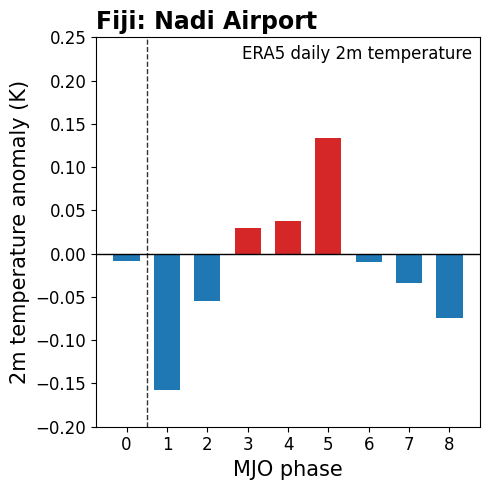

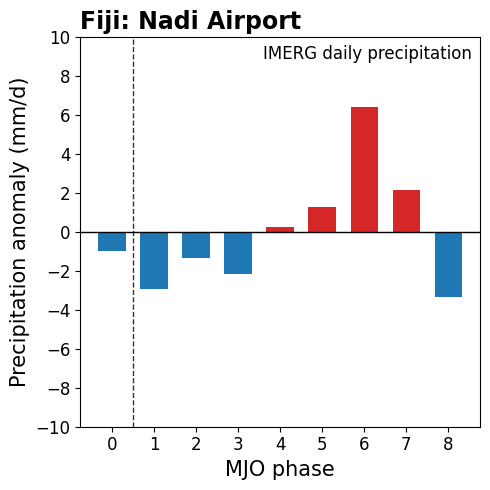

In [ ]:
download_countrydata(my_country, selected_station, month_start=month_strt, month_end=month_end)

# Section B. Phase frequency and interpretation   

In this section, we examine the frequency of each MJO phase.  
Earlier, we used `MJO_phase` and `MJO_amplitude` to seperate each variable by MJO phase.   
Here, instead of applying them directly to the variables, we use the MJO indices themselves to investigate phase frequency in selected years.   
Note that, in the previous analysis, `t2m` and `precipitation` were restricted to the selected season.   
Year 1980 to 2025 is provided here.

In [ ]:
year = 2020
count_phase_time(year = year)

Counted days for each MJO phase in year 2020:

           count (days)
MJO phase              
0                    94
1                    36
2                    52
3                    27
4                    43
5                    57
6                    27
7                    13
8                    17
